# Neural Networks from Scratch

This notebook demonstrates building neural networks from scratch using custom implementations of layers, optimizers, and training procedures.

## 1. Setup and Imports

In [ ]:
from datasets import DataLoader, DummyDataset, FashionMNISTDataset
from datasets.utils.random_split import random_split

from datasets.utils.trasnforms import (
    Compose,
    ToFloat,
    Normalize,
    Scale,
)

from network import Network
from layers import ReLU, Linear, Flatten, Dropout

from losses import SoftmaxCrossEntropy
from optimizers.scheduler import StepLR
from optimizers import Adam

from train import Trainer
from eval import Evaluator

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 2. Dummy Dataset - Overfitting Example

Demonstrating network overfitting on a small synthetic dataset.

In [6]:
batch_size = 4

train_dataset = DummyDataset(
    num_samples=20,
    num_features=10,
    num_classes=3,
    seed=42,
)

val_dataset = train_dataset

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    drop_last=False,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    drop_last=False,
    shuffle=False
)

model = Network([
    Linear(10, 150),
    ReLU(),
    Linear(150, 3)
])

loss_func = SoftmaxCrossEntropy()
optimizer = Adam(
    parameters=model.parameters(), 
    learning_rate=1e-3,
    weight_decay=1e-4
)

trainer = Trainer(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_func=loss_func,
    optimizer=optimizer
)

history = trainer.train(epochs=20)

(Epoch 1 / 20) train loss: 1.066714; train accuracy: 0.3500; val loss: 0.961233; val accuracy: 0.3500
(Epoch 2 / 20) train loss: 0.927118; train accuracy: 0.4500; val loss: 0.862797; val accuracy: 0.5000
(Epoch 3 / 20) train loss: 0.834521; train accuracy: 0.5000; val loss: 0.781443; val accuracy: 0.6000
(Epoch 4 / 20) train loss: 0.757254; train accuracy: 0.6000; val loss: 0.711853; val accuracy: 0.7000
(Epoch 5 / 20) train loss: 0.696697; train accuracy: 0.7000; val loss: 0.652394; val accuracy: 0.7500
(Epoch 6 / 20) train loss: 0.636610; train accuracy: 0.7500; val loss: 0.602853; val accuracy: 0.8000
(Epoch 7 / 20) train loss: 0.588411; train accuracy: 0.8500; val loss: 0.559426; val accuracy: 0.8500
(Epoch 8 / 20) train loss: 0.549801; train accuracy: 0.8500; val loss: 0.520588; val accuracy: 0.9000
(Epoch 9 / 20) train loss: 0.513420; train accuracy: 0.9000; val loss: 0.486652; val accuracy: 0.9000
(Epoch 10 / 20) train loss: 0.478378; train accuracy: 0.9000; val loss: 0.456072; 

## 3. Fashion MNIST Dataset

### 3.1 Data Loading and Preprocessing

In [8]:
data_path = "data/fashion-mnist/train-images-idx3-ubyte"
labels_path = "data/fashion-mnist/train-labels-idx1-ubyte"

transform = Compose([
    ToFloat(),
    Scale(255.0),
    Normalize(mean=0.2860, std=0.3530),
])

dataset = FashionMNISTDataset(
    data_path=data_path,
    labels_path=labels_path,
    transform=transform,
)

splits = random_split(
    dataset,
    {"train": 0.8, "val": 0.2},
    seed=42,
)

train_dataset = splits["train"]
val_dataset = splits["val"]

### 3.2 DataLoader Setup

In [9]:
batch_size = 128

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=False,
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=batch_size,
    shuffle=False,
    drop_last=False,
)

## 4. Model Architecture

Building a neural network with two hidden layers, ReLU activations, and dropout for regularization.

In [10]:
model = Network([
    Flatten(),
    Linear(784, 1024),
    ReLU(),
    Dropout(0.1),

    Linear(1024, 512),
    ReLU(),
    Dropout(0.1),

    Linear(512, 10),
], model_name="fashion-mnist-nn")

## 5. Training Configuration

Configure the loss function, optimizer with weight decay, and learning rate scheduler.

In [11]:
lr = 1e-3
wd = 5e-5

loss_func = SoftmaxCrossEntropy()
optimizer = Adam(
    parameters=model.parameters(),
    learning_rate=1e-3,
    weight_decay=wd
)
scheduler = StepLR(
    optimizer,
    step_size=10,
    gamma=0.5
)

## 6. Training

Train the model for 30 epochs with checkpointing based on validation accuracy.

In [12]:
epochs = 30

trainer = Trainer(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_func=loss_func,
    optimizer=optimizer,
    scheduler=scheduler,
)

history = trainer.train(epochs=epochs, checkpoint_monitor="accuracy", checkpoint_mode="max")

(Epoch 1 / 30) train loss: 0.496847; train accuracy: 0.8233; val loss: 0.397167; val accuracy: 0.8504
(Epoch 2 / 30) train loss: 0.356101; train accuracy: 0.8694; val loss: 0.396183; val accuracy: 0.8510
(Epoch 3 / 30) train loss: 0.319057; train accuracy: 0.8805; val loss: 0.368055; val accuracy: 0.8625
(Epoch 4 / 30) train loss: 0.298956; train accuracy: 0.8881; val loss: 0.352323; val accuracy: 0.8718
(Epoch 5 / 30) train loss: 0.273022; train accuracy: 0.8982; val loss: 0.331150; val accuracy: 0.8772
(Epoch 6 / 30) train loss: 0.259243; train accuracy: 0.9030; val loss: 0.343268; val accuracy: 0.8743
(Epoch 7 / 30) train loss: 0.249646; train accuracy: 0.9065; val loss: 0.326082; val accuracy: 0.8855
(Epoch 8 / 30) train loss: 0.238878; train accuracy: 0.9095; val loss: 0.332731; val accuracy: 0.8825
(Epoch 9 / 30) train loss: 0.226527; train accuracy: 0.9146; val loss: 0.336479; val accuracy: 0.8823
(Epoch 10 / 30) train loss: 0.216304; train accuracy: 0.9188; val loss: 0.328443; 

## 7. Loss curves


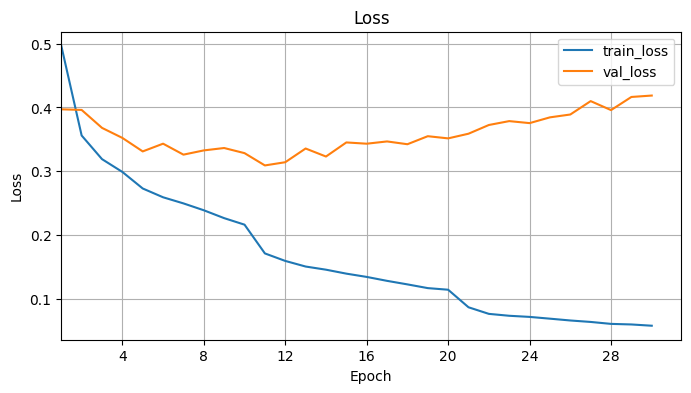

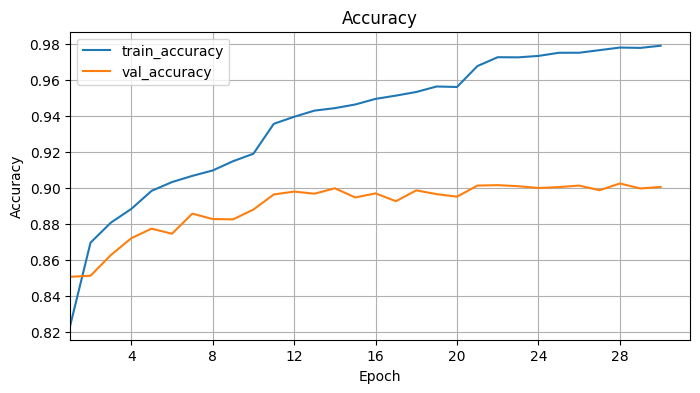

In [19]:
history.plot_loss()
history.plot_accuracy()

## 8. Model Persistence and Testing

### 8.1 Save Model

Save the trained model to disk for later use.

In [13]:
model.save_model()

### 8.2 Load Model

Load a previously trained model from disk and use it for inference.

In [17]:
# Load the model from disk
model = Network([
    Flatten(),
    Linear(784, 1024),
    ReLU(),
    Dropout(0.1),

    Linear(1024, 512),
    ReLU(),
    Dropout(0.1),

    Linear(512, 10),
], model_name="fashion-mnist-nn")

model = Network.load_model(
    model=model,
    model_name="fashion-mnist-nn"
)


### 8.3 Test Data Preparation

In [24]:
test_data_path = "data/fashion-mnist/t10k-images-idx3-ubyte"
test_labels_path = "data/fashion-mnist/t10k-labels-idx1-ubyte"

test_dataset = FashionMNISTDataset(
    data_path=test_data_path,
    labels_path=test_labels_path,
    transform=transform,
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=128,
    drop_last=False,
    shuffle=False,
)

### 8.4 Evaluating performance on test set

In [25]:
evaluator = Evaluator(
    model=model,
    class_names=FashionMNISTDataset.CLASS_NAMES
)

results = evaluator.evaluate(test_loader)
print(f"Model accuracy: {results["accuracy"]}")


Model accuracy: 0.8924


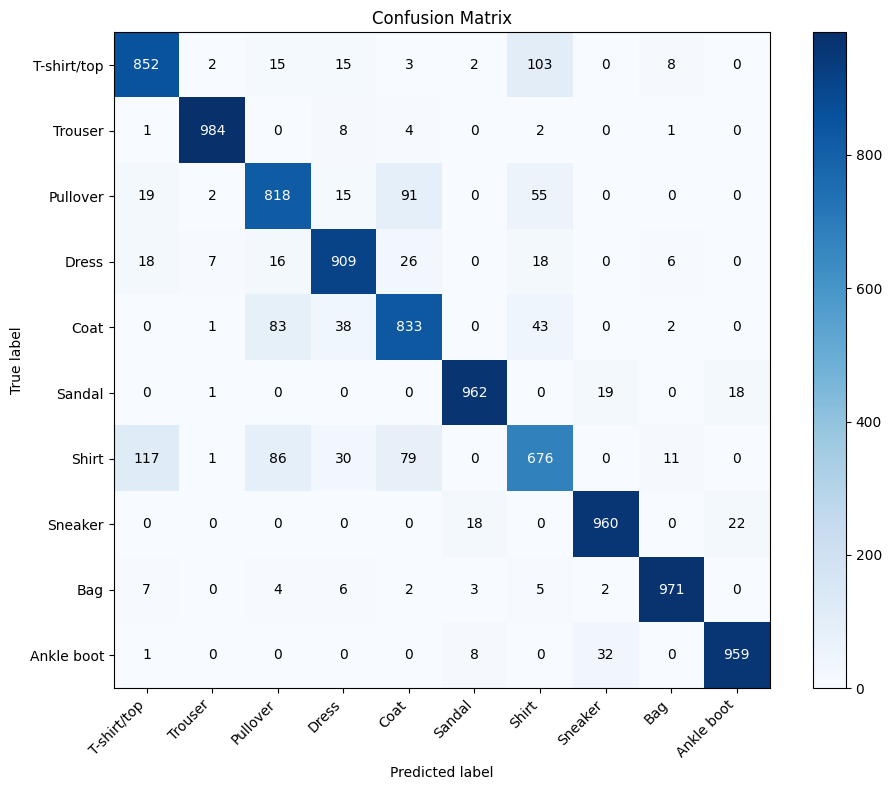

In [28]:
evaluator.plot_confusion_matrix(results)

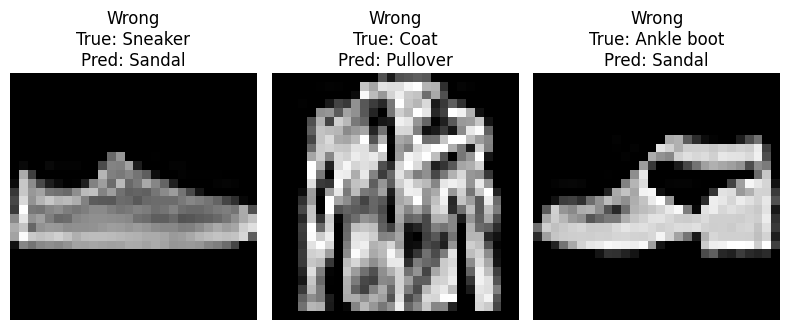

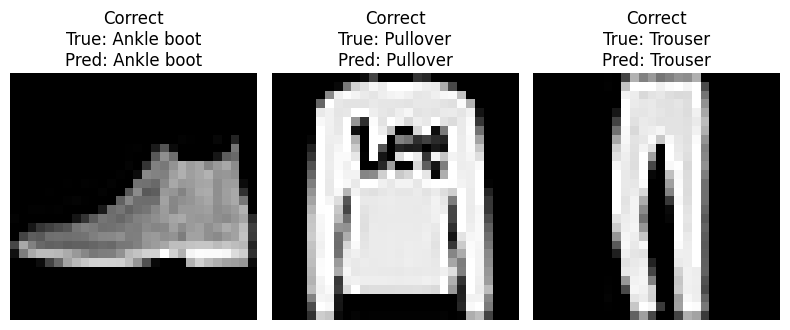

In [30]:
evaluator.plot_wrong_predictions(
    results,
    max_images=3,
    image_shape=(28, 28)
)

evaluator.plot_correct_predictions(
    results,
    max_images = 3,
    image_shape=(28, 28)
)